# Tutorial \#7 (23 Feb. 2024)

Faisal Jayousi 

jayousi@unice.fr

## What is DeepInverse all about?
DeepInverse is a Pytorch based Python module for solving imaging inverse problems with Deep Learning. If provides a range of linear and non-linear forward operators, such as blurring, denoising and downsampling.

## Importing DeepInverse
* You need to install the DeepInverse module for this tutorial: ```pip install deepinv```
* To import it: use ```import deepinv```
* Documentation: https://deepinv.github.io/deepinv/index.html

In [2]:
!pip install deepinv

   ---------------------------------------- 0.0/516.8 kB ? eta -:--:--
   --------------- ------------------------ 194.6/516.8 kB 5.9 MB/s eta 0:00:01
   ---------------------------------------- 516.8/516.8 kB 6.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/64.4 kB ? eta -:--:--
   ---------------------------------------- 64.4/64.4 kB ? eta 0:00:00
   ---------------------------------------- 0.0/53.6 kB ? eta -:--:--
   ---------------------------------------- 53.6/53.6 kB 2.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/927.3 kB ? eta -:--:--
   ------------------------------- ------- 757.8/927.3 kB 24.1 MB/s eta 0:00:01
   --------------------------------------- 927.3/927.3 kB 14.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/20.3 MB ? eta -:--:--
   -- ------------------------------------- 1.1/20.3 MB 34.4 MB/s eta 0:00:01
   --- ------------------------------------ 1.8/20.3 MB 19.3 MB/s eta 0:00:01
   ---- ---------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-nightly-intel 2.17.0.dev20240229 requires keras-nightly~=3.1.0.dev, which is not installed.
tf-nightly-intel 2.17.0.dev20240229 requires ml-dtypes~=0.3.1, but you have ml-dtypes 0.5.1 which is incompatible.
anaconda-cloud-auth 0.1.3 requires pydantic<2.0, but you have pydantic 2.10.6 which is incompatible.
langchain 0.0.225 requires pydantic<2,>=1, but you have pydantic 2.10.6 which is incompatible.
langchainplus-sdk 0.0.20 requires pydantic<2,>=1, but you have pydantic 2.10.6 which is incompatible.
tensorflow-intel 2.15.0 requires ml-dtypes~=0.2.0, but you have ml-dtypes 0.5.1 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import deepinv as dinv
import matplotlib.pyplot as plt
import torch

import numpy as np
import random

## LISTA

The subject of this tutorial is LISTA (Learned Iterative Soft-Thresholding Algorithm). The main difference with the classical ISTA algorithm is that the thresholding parameters of the proximal operator are learned. For a use-case in compressed sensing, see https://deepinv.github.io/deepinv/auto_examples/unfolded/demo_LISTA.html.

**NB**: Using a GPU for this tutorial is recommended. However, the parameters have been modestly adjusted to ensure efficient execution on a CPU in minimal time.

The steps are as follows:
1. Data generation: as a first approach, we will use the well-known MNIST dataset. It can be downloaded using ```datasets.MNIST()```. See the documentation for more details on the arguments.
2. Generate blurred images: you can use ```dinv.datasets.generate_dataset()```. An appropriate blurring model needs to be defined first. For simplicity, choose a gaussian kernel with $\sigma=3$.
3. Load the data using PyTorch's dataloaders. Don't forget to shuffle the training data. You may use DeepInverse's ```datasets.HDF5Dataset()```.
4. Train using the training data. See DeepInverse's ```training_utils```.
5. Test your model on the test dataset. Plot the learned stepsize and regularisastion parameter.
6. Test your model on a generated SMLM image. How well does it work?
7. Redo everything but with generated SMLM images (use ~250 images for training).


### Data generation

In [2]:
# Function to generate an SMLM image
def generate_ground_truth(n: int, n_mol: int, margin: int) -> np.ndarray:
    """
    n: shape of output
    n_mol: number of molecules
    margin: to avoid placing molecules near the edges
    """
    gt = np.zeros((n, n), dtype=np.double)
    for _ in np.arange(n_mol):
        i = random.randint(margin, n-margin)
        j = random.randint(margin, n-margin)
        gt[i, j] = 255.
    return gt

In [3]:
# Reproducibility
torch.manual_seed(0)
random.seed(234)

device = dinv.utils.get_freer_gpu() if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [4]:
img_size = 28
n_channels = 1
operation = "blur"
train_dataset_name = "MNIST_train"

# Download MNIST dataset in HDF5 folders and load them.
# train_test_transform = ...
# train_base_dataset = ...
# test_base_dataset = ...

import deepinv as dinv
from torchvision import datasets, transforms

# save_dir = dinv.utils.demo.get_data_home() / 'MNIST'

save_dir = dinv.utils.demo.get_data_home() / 'MNIST'

train_test_transform = transforms.Compose([transforms.ToTensor()])
train_base_dataset = datasets.MNIST(root=save_dir, train=True,
                            transform=train_test_transform, download=True)
test_base_dataset = datasets.MNIST(root=save_dir, train=False, transform=train_test_transform)

In [5]:
num_workers = 0

# # Generate the forward operator
# physics = ...
physics = dinv.physics.Blur(filter = dinv.physics.blur.gaussian_blur(sigma=(1, 1), angle=0), device = device, img_shape = (1,28,28),fast = True)


my_dataset_name = "demo_LISTA"
n_images_max = 200  # number of images used for training

# generated_datasets_path = ...
# measurement_dir = DATA_DIR / train_dataset_name / operation
measurement_dir = "C:/sers/praba/Documents/GitHub/UCA-M2-SEMESTER2/Inverse problems in biological imaging/TD 7"
generated_datasets_path = dinv.datasets.generate_dataset(
    train_dataset=train_base_dataset,
    test_dataset=test_base_dataset,
    physics=physics,
    device=device,
    save_dir=measurement_dir,
    train_datapoints=n_images_max,
    test_datapoints=8,
    num_workers=num_workers,
    dataset_filename=str(my_dataset_name),
)
# # Load datasets
# train_dataset = ...
# test_dataset = ...


train_dataset = dinv.datasets.HDF5Dataset(path=generated_datasets_path, train=True)
test_dataset = dinv.datasets.HDF5Dataset(path=generated_datasets_path, train=False)

C:\Users\praba\anaconda3\Lib\site-packages\deepinv\datasets\datagenerator.py:214: UserWarning: Dataset C:/sers/praba/Documents/GitHub/UCA-M2-SEMESTER2/Inverse problems in biological imaging/TD 7/demo_LISTA0.h5 already exists, this will overwrite the previous dataset.
  warn(


Dataset has been saved at C:/sers/praba/Documents/GitHub/UCA-M2-SEMESTER2/Inverse problems in biological imaging/TD 7/demo_LISTA0.h5


### Define algorithm

Same as in the previous tutorials, we will solve the following problem $$\min_x \frac{1}{2}\|Ax-y\|_2^2 + \lambda\|x\|_1$$

In this tutorial, we will focus exclusively on $\ell^1$ regularisation. However, the module provides a wide range of intriguing priors, both classical and learnable. For further details, refer to https://deepinv.github.io/deepinv/deepinv.models.html. Additionally, we will optimise the selection of $\lambda$.

In [44]:
max_iter = 10

# data_fidelity = ...
data_fidelity = dinv.optim.L2(sigma=1.0)

# prior = ...
prior = dinv.optim.Prior(deepinv.optim.L1() for _ in range(max_iter))
# initialisation
# lamb = ...
# stepsize = ...


lamb = [1 for a in range(max_iter)]


stepsize = [torch.ones(1, device=device)] * max_iter  # initialization of the stepsizes.

sigma_denoiser_init = 0.05
# sigma_denoiser = ...
sigma_denoiser = [
    torch.ones(1, 1, device=device)
    * sigma_denoiser_init  
] * max_iter 



# params_algo = {}
params_algo = {"stepsize": stepsize,"lambda": lamb }


trainable_params = ["stepsize",
    "lambda"]

# model = ...

model = dinv.unfolded.unfolded_builder(
    iteration="PGD",
    params_algo=params_algo.copy(),
    trainable_params=trainable_params,
    data_fidelity=data_fidelity,
    max_iter=max_iter,
    prior=prior,
).to(device)

In [45]:
# Training parameters
epochs = 4
learning_rate = 1e-3


# Choose optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# Choose supervised training loss
losses = [dinv.loss.SupLoss(metric=dinv.metric.MSE())]

# Logging parameters
verbose = True
wandb_vis = False  # plot curves and images in Weight&Bias

# Batch sizes and data loaders
train_batch_size = 1
test_batch_size = 8

# train_dataloader = ...
# test_dataloader = ...

train_dataloader = torch.utils.data.DataLoader( train_dataset, batch_size= train_batch_size, num_workers=0, shuffle=True)
test_dataloader =  torch.utils.data.DataLoader( test_dataset, batch_size= test_batch_size, num_workers=0, shuffle=False)

In [46]:
CKPT_DIR = "C:/Users/praba/Documents/GitHub/UCA-M2-SEMESTER2/Inverse problems in biological imaging/TD 7/datasets"

In [49]:
# Train model
...
from pathlib import Path
BASE_DIR = Path("C:/Users/praba/Documents/GitHub/UCA-M2-SEMESTER2/Inverse problems in biological imaging/TD 7/datasets")
DATA_DIR = BASE_DIR / "measurements"
RESULTS_DIR = BASE_DIR / "results"
CKPT_DIR = BASE_DIR / "ckpts"

trainer = dinv.Trainer(
    model,
    physics=physics,
    train_dataloader=train_dataloader,
    eval_dataloader=test_dataloader,
    epochs=epochs,
    losses=losses,
    optimizer=optimizer,
    device=device,
#     save_path=str(CKPT_DIR / operation),
    verbose=verbose)

In [50]:
model = trainer.train()


The model has 20 trainable parameters


Train epoch 1/4:   0%|                                                                                                        | 0/200 [00:00<?, ?it/s]


TypeError: 'generator' object is not callable

Processing data of operator 1 out of 1


  0%|          | 0/1 [00:00<?, ?it/s]

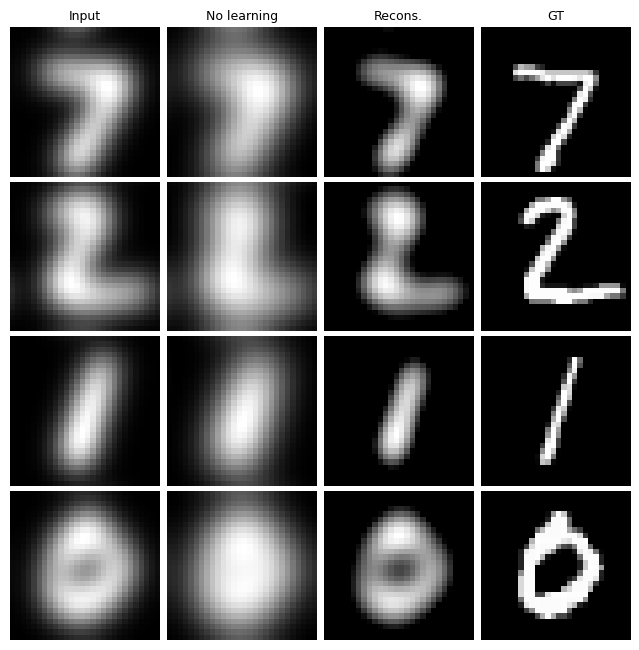

100%|██████████| 1/1 [00:04<00:00,  4.05s/it]

Test PSNR: No learning rec.: 12.70+-0.00 dB | Model: 14.34+-0.00 dB. 


(14.339180946350098, 0.0, 12.69517993927002, 0.0)

In [10]:
# Test model and plot results

In [42]:
trainer.test(test_dataloader)

test_sample, _ = next(iter(test_dataloader))
model.eval()
test_sample = test_sample.to(device)

# Get the measurements and the ground truth
y = physics(test_sample)
with torch.no_grad():  # it is important to disable gradient computation during testing.
    rec = model(y, physics=physics)

backprojected = physics.A_adjoint(y)

dinv.utils.plot(
    [backprojected, rec, test_sample],
    titles=["Linear", "Reconstruction", "Ground truth"],
    suptitle="Reconstruction results",
)

Test:   0%|                                                                                                                     | 0/1 [00:00<?, ?it/s]


TypeError: 'generator' object is not callable

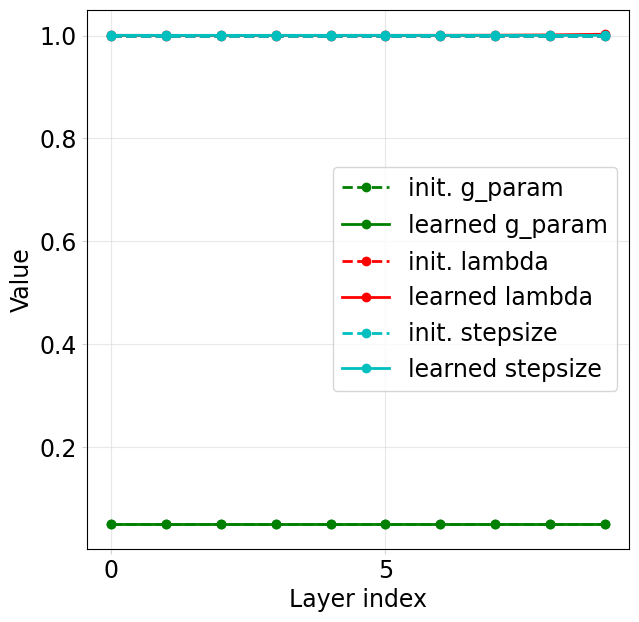

<Figure size 640x480 with 0 Axes>

### Test on SMLM image

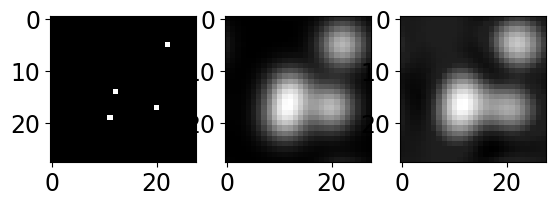

In [13]:
gt = generate_ground_truth(28, 4, 4)
gt = torch.from_numpy(gt).to(torch.float)


blurred_image = ...
out = ...

plt.subplot(131)
plt.imshow(gt, cmap='gray')
plt.subplot(132)
plt.imshow(blurred_image[0, 0], cmap="gray")
plt.subplot(133)
plt.imshow(out.detach().numpy()[0, 0], cmap='gray')
plt.show()

### Retraining on SMLM images